# `06-workflow.ipynb`

In [ ]:
from dotenv import load_dotenv
from langchain.chat_models import init_chat_model
load_dotenv()

llm = init_chat_model('gpt-4.1-mini')

## Prompt Chaining

- 매우 잘 정리된 업무 순서가 있을 경우 사용
- 이전 노드에서 처리한 내용을 `state` 에 담아 다음 노드로 전송

In [ ]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END
# 그림 보는 용
from IPython.display import Image, display


# Graph State
class State(TypedDict):
    topic: str
    joke: str
    improved_joke: str
    final_joke: str


# Nodes
def generate_joke(state: State):
    msg = llm.invoke(f'주제 {state['topic']}에 관련된 짧은 농담 생성')
    return {'joke': msg.content}


def improve_joke(state: State):
    msg = llm.invoke(f'말장난을 추가해서 아래 농담을 더 재밌게 만들어보자.\n {state['joke']}')
    return {'improved_joke': msg.content}


def polish_joke(state: State):
    msg = llm.invoke(f'아래 농담을 쩔게 뒤틀어 보자. \n {state['improved_joke']}')
    return {'final_joke': msg.content}


# Router
def check_punchline(state: State):
    # ? 나 ! 없으면, 농담을 improve 하고, 있으면 그대로 진행
    if '?' in state['joke'] or '!' in state['joke']:
        return 'Pass'
    else:
        return 'Fail'
    

workflow = StateGraph(State)

# 조립
workflow.add_node(generate_joke)
workflow.add_node(improve_joke)
workflow.add_node(polish_joke)

workflow.add_edge(START, 'generate_joke')
workflow.add_conditional_edges(
    'generate_joke',
    check_punchline,
    {
        'Pass': END,
        'Fali': 'improve_joke'
    }
)
workflow.add_edge('improve_joke', 'polish_joke')
workflow.add_edge('polish_joke', END)

graph = workflow.compile()

display(Image(graph.get_graph().draw_mermaid_png()))


graph.invoke({'topic': '랭체인'})

## Parallelization (병렬화) (비동기)
- 여러 node(llm)이 동시에 작업을 진행
- 뭐가 먼저 끝날지 알 수 없음
- 하위 태스크를 동시에 진행시켜서 속도 up
- 같은 태스크를 여러번 동시에 돌려서 신뢰성 확보

In [ ]:
class State(TypedDict):
    topic: str
    joke: str
    story: str
    poem: str
    output: str


# Nodes
def generate_joke(state: State):
    msg = llm.invoke(f'Write a joke about {state['topic']}')
    return {'joke': msg.content}


def generate_story(state: State):
    msg = llm.invoke(f'Write a story about {state['topic']}')
    return {'story': msg.content}


def generate_poem(state: State):
    msg = llm.invoke(f'Write a poem about {state['topic']}')
    return {'poem': msg.content}


def aggregate(state: State):
    output = f"""농담, 이야기, 시
Joke: {state['joke']} `
Story: {state['story']}
Poem: {state['poem']}
"""
    return {'output': output}


workflow = StateGraph(State)
workflow.add_node(generate_joke)
workflow.add_node(generate_poem)
workflow.add_node(generate_story)
workflow.add_node(aggregate)

workflow.add_edge(START, 'generate_joke')
workflow.add_edge(START, 'generate_poem')
workflow.add_edge(START, 'generate_story')
workflow.add_edge('generate_joke', 'aggregate')
workflow.add_edge('generate_poem', 'aggregate')
workflow.add_edge('generate_story', 'aggregate')
workflow.add_edge('aggregate', END)

graph = workflow.compile()

display(Image(graph.get_graph().draw_mermaid_png()))
graph.invoke({'topic': '봄'})

In [ ]:
from typing import Literal
from langchain.messages import HumanMessage, SystemMessage
from pydantic import BaseModel, Field


class State(TypedDict):
    input: str
    decision: str
    output: str


# Router 에서 사용할 LLM이 쓸 structured output
# {'step': 'poem' | 'story' | 'joke'}
class Route(BaseModel):
    # step 이란 필드는 3개중 하나지만, 필수(...)고 설명은 ~~하다
    step: Literal['poem', 'story', 'joke'] = Field(..., description='next step in routing process')

router_llm = llm.with_structured_output(Route)


# state['decision'] 을 결정하는 Node
def decision_node(state: State):
    result = router_llm.invoke(
        [
            SystemMessage(content='사용자 요청에 따라 story, joke, poem 을 선택'),
            HumanMessage(content=state['input'])
        ]
    )
    return {'decision': result.step}


def generate_joke(state: State):
    msg = llm.invoke([
        SystemMessage(content='아주 기발하되 고급스러운 유머를 만들어야 함'),
        HumanMessage(content=state['input'])
    ])
    return {'output': msg.content}


def generate_story(state: State):
    msg = llm.invoke(state['input'])
    return {'output': msg.content}


def generate_poem(state: State):
    msg = llm.invoke(state['input'])
    return {'output': msg.content}


# Router
def route_decision(state: State):
    return state['decision']


workflow = StateGraph(State)
workflow.add_node(decision_node)
workflow.add_node(generate_joke)
workflow.add_node(generate_poem)
workflow.add_node(generate_story)

workflow.add_edge(START, 'decision_node')
workflow.add_conditional_edges(
    'decision_node',
    route_decision,
    {
        'joke': 'generate_joke',
        'story': 'generate_story',
        'poem': 'generate_poem'
    }
)
workflow.add_edge('generate_joke', END)
workflow.add_edge('generate_story', END)
workflow.add_edge('generate_poem', END)
graph = workflow.compile()

display(Image(graph.get_graph().draw_mermaid_png()))
graph.invoke({'input': '심심해'})

## Orchestrator - Worker
- 태스크를 서브태스크로 쪼갬
- 해당 서브태스크를 담당하는 워커에게 분배
- 모든 서브태스크들의 output을 최종 결과로 정리

In [ ]:
from typing import Annotated, List
from pydantic import BaseModel, Field

# Structured Output 용 Model 생성 (계획수립용)
class Section(BaseModel):
    name: str = Field(
        ...,
        description='보고서내 해당 섹션명'
    )
    description: str = Field(
        ...,
        description='해당 섹션에서 다룰 주요 주제 및 개념에 대한 개요'
    )


class Sections(BaseModel):
    sections: List[Section] = Field(
        ...,
        description='리포트의 섹션들'
    )

planner_llm = llm.with_structured_output(Sections)
planner_llm.invoke('LLM 스케일링 법칙에 대한 레포트 작성해줘')

In [ ]:
import operator
from langgraph.types import Send  # 유동적으로 worker 노드를 실행

# Graph State
class State(TypedDict):
    topic: str
    sections: list[Section]
    completed_sections : Annotated[list, operator.add]
    final_report: str


# Worker State
class WorkerState(TypedDict):
    section: Section
    completed_sections: Annotated[list, operator.add]


# Nodes
def orchestrator(state: State):
    report_sections = planner_llm.invoke(
        [
            SystemMessage(content='Generate a plan for report.'),
            HumanMessage(content=f'Here is the report topic: {state['topic']}'),
        ]
    )

    return {'sections': report_sections.sections}


def worker(state: WorkerState):
    section = llm.invoke(
        [
            SystemMessage(content='제공된 name 과 description에 따라 보고서 섹션을 작성해라. 각 섹션 앞에는 서두를 넣지 말고, md 형식으로 작성.'),
            HumanMessage(content=f'섹션 name: {state['section'].name} \n섹션 description: {state['section'].description}'),
        ]
    )
    return {'completed_sections': [section.content]}


def synthesizer(state: State):
    # 단순히 worker 들의 결과 합치기
    completed_sections = state['completed_sections']
    final_report = '\n\n ------------- \n\n'.join(completed_sections)
    return {'final_report': final_report}


# Router
def assign_workers(state: State):
    plan = []
    for s in state['sections']:
        plan.append(Send('worker', {'section': s}))
    
    return plan


# Graph
workflow = StateGraph(State)

workflow.add_node(orchestrator)
workflow.add_node(worker)
workflow.add_node(synthesizer)

workflow.add_edge(START, 'orchestrator')
workflow.add_conditional_edges(
    'orchestrator',
    assign_workers,
    ['worker']
)

workflow.add_edge('worker', 'synthesizer')
workflow.add_edge('synthesizer', END)

graph = workflow.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

result = graph.invoke({'topic': 'LLM 스케일링 법칙에 대한 리포트 작성'})

In [ ]:
from IPython.display import Markdown
Markdown(result['final_report'])

In [31]:
# worker node 함수 내부에 langchain agent 배치
# langchain agent 에게 websearch tool 배치 (Tavily Websearch)
import os
from dotenv import load_dotenv
from tavily import TavilyClient
from langchain.tools import tool
from langchain.agents import create_agent

load_dotenv()

TAVILY_API_KEY = os.getenv('TAVILY_API_KEY')
tavily_client = TavilyClient(api_key=TAVILY_API_KEY)


@tool
def websearch_tool(
    query: str,
    max_results: int = 5,  # = 뒤에는 기본값
    topic: Literal['general', 'news', 'finance'] = 'general',
    include_raw_content: bool = False,
):
    """Run a web search"""
    return tavily_client.search(
        query,
        max_results=max_results,
        include_raw_content=include_raw_content,
        topic=topic
    )

AGENT_SYSTEM_PROMPT = """너는 도움이 되는 Agent야.

websearch_tool 을 활용해서 리포트를 작성하는데 필요한 정보를 가져와.
Use this to run an internet search for a given query. You can specify the max number of results to return, the topic, and whether raw content should be included.

최종적으로 제공된 name 과 description에 따라 보고서 섹션을 작성해라. 
각 섹션 앞에는 서두를 넣지 말고, md 형식으로 작성.
"""


agent = create_agent(
        llm,
        tools=[websearch_tool],
        system_prompt=AGENT_SYSTEM_PROMPT,
)

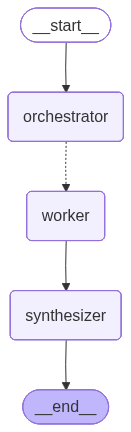

c:\Users\user\Desktop\gaida-2\05-langgraph\.venv\Lib\site-packages\pydantic\main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=Sections(sections=[Sectio...향후 전망 제시')]), input_type=Sections])
  return self.__pydantic_serializer__.to_python(


In [34]:
from typing import Annotated, List
from pydantic import BaseModel, Field
import operator
from langgraph.types import Send  


class Section(BaseModel):
    name: str = Field(
        ...,
        description='보고서내 해당 섹션명'
    )
    description: str = Field(
        ...,
        description='해당 섹션에서 다룰 주요 주제 및 개념에 대한 개요'
    )


class Sections(BaseModel):
    sections: List[Section] = Field(
        ...,
        description='리포트의 섹션들'
    )


# Graph State
class State(TypedDict):
    topic: str
    sections: list[Section]
    completed_sections : Annotated[list, operator.add]
    final_report: str


# Worker State
class WorkerState(TypedDict):
    section: Section
    completed_sections: Annotated[list, operator.add]


# Nodes
def orchestrator(state: State):
    report_sections = planner_llm.invoke(
        [
            SystemMessage(content='Generate a plan for report.'),
            HumanMessage(content=f'Here is the report topic: {state['topic']}'),
        ]
    )

    return {'sections': report_sections.sections}


def worker(state: WorkerState):
    message = f'섹션 name: {state['section'].name} \n섹션 description: {state['section'].description}'
    result = agent.invoke(
        {
            'messages': [HumanMessage(content=message),]
        })

    # 결과 messages안에 Human, AI, Tool 등등 다 빼고 마지막 AI 메세지의 내용만 사용
    return {'completed_sections': [result['messages'][-1].content]}


def synthesizer(state: State):
    # 단순히 worker 들의 결과 합치기
    completed_sections = state['completed_sections']
    final_report = '\n\n ------------- \n\n'.join(completed_sections)
    return {'final_report': final_report}


# Router
def assign_workers(state: State):
    plan = []
    for s in state['sections']:
        plan.append(Send('worker', {'section': s}))
    
    return plan


# Graph
workflow = StateGraph(State)

workflow.add_node(orchestrator)
workflow.add_node(worker)
workflow.add_node(synthesizer)

workflow.add_edge(START, 'orchestrator')
workflow.add_conditional_edges(
    'orchestrator',
    assign_workers,
    ['worker']
)

workflow.add_edge('worker', 'synthesizer')
workflow.add_edge('synthesizer', END)

graph = workflow.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

result = graph.invoke({'topic': 'AI + 2035 논문이 발표되었는데, 내용과 시사점을 정리해줘'})

## Evaluator - Optimizer (평가 - 최적화)
- 답변 생성용 LLM 과 답변 평가용 LLM
- 만족스러운 평가가 될때까지 응답 재생성
- "성공" 기준이 매우 명확할 때 사용. 

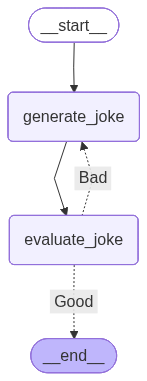

In [40]:
class State(TypedDict):
    joke: str
    topic: str
    feedback: str
    funny_or_not: str


# 평가 담당 llm이 사용할 structured output schema
class Feedback(BaseModel):
    grade: Literal['funny', 'not funny'] = Field(
        ...,
        description='농담이 재밌는지 아닌지 판단'
    )
    feedback: str = Field(
        description='농담이 재미 없다면, 발전시킬 수 있도록 피드백 제공'
    )

evaluator_llm = llm.with_structured_output(Feedback)


# Nodes
def generate_joke(state: State):
    # 평가 x 당하고 다시 만들어야 하는 상황
    if state.get('feedback'):
        msg = llm.invoke(
            f'{state['topic']}관련된 농담을 작성하되, 피드백 참고({state['feedback']})'
        )
    # 첫 트라이
    else:
        msg = llm.invoke(
            f'{state['topic']}관련된 농담을 작성.'
        )
    return {'joke': msg.content}


def evaluate_joke(state: State):
    result = evaluator_llm.invoke(f'다음 농담을 엄근진하게 평가 하시오. <{state['joke']}>')
    return {'funny_or_not': result.grade, 'feedback': result.feedback}


# Router
def route_joke(state: State):
    if state['funny_or_not'] == 'funny':
        return 'Good'
    elif state['funny_or_not'] == 'not funny':
        return 'Bad'
    

workflow = StateGraph(State)
workflow.add_node(generate_joke)
workflow.add_node(evaluate_joke)

workflow.add_edge(START, 'generate_joke')
workflow.add_edge('generate_joke', 'evaluate_joke')
workflow.add_conditional_edges(
    'evaluate_joke',
    route_joke,
    {
        'Good': END,
        'Bad': 'generate_joke'
    }
)

graph = workflow.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

In [41]:
graph.invoke({'topic': '주식'})

c:\Users\user\Desktop\gaida-2\05-langgraph\.venv\Lib\site-packages\pydantic\main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=Feedback(grade='not funny...기 어렵습니다.'), input_type=Feedback])
  return self.__pydantic_serializer__.to_python(
c:\Users\user\Desktop\gaida-2\05-langgraph\.venv\Lib\site-packages\pydantic\main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=Feedback(grade='not funny...가 부족합니다.'), input_type=Feedback])
  return self.__pydantic_serializer__.to_python(
c:\Users\user\Desktop\gaida-2\05-langgraph\.venv\Lib\site-packages\pydantic\main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', i

{'joke': '주식 투자자들이 집값 변동을 보며 하는 말:\n"주식은 롤러코스터, 집값은 놀이공원 탈출 게임 같아. 둘 다 손에 땀을 쥐게 만들지만, 집값은 내려가면 \'탈출 확인\', 주식은 내려가면 \'재빨리 다시 탑승\'이지!" \n\n이렇게 변동성 앞에선 투자자들도 결국엔 같은 놀이기구에서 똑같이 멘붕한다는 뜻을 담아봤습니다.',
 'topic': '주식',
 'feedback': "이 농담은 주식과 부동산 투자의 변동성을 유희적인 놀이공원 놀이기구에 비유하여, 투자자들이 마주하는 불안과 혼란을 재치있게 표현했습니다. '롤러코스터'와 '탈출 게임'이라는 대조적인 이미지로 양쪽 시장의 특성을 살리면서, 최종적으로 모든 투자자가 같은 불안 속에 있다는 메시지가 잘 전달되어 웃음을 자아냅니다.",
 'funny_or_not': 'funny'}